# Data Notebook
This notebook demonstrates how to fetch historical market capitalization for a set of tickers using the helpers in `qf/core/data.py`, visualize the results, and export them to CSV.

In [1]:
# Imports and setup
import pandas as pd
from datetime import datetime
from qf.core.data import get_historical_market_cap, export_market_cap_to_csv, get_instruments_data, plot_time_series, get_yahoo_components_for_index_symbol

In [36]:
# Select sample tickers (S&P 500 list intersect or explicit selection)
try:
    sp = get_instruments_data(columns=['symbol'])
    tickers = sp['symbol'].head(10).tolist()  # take first 10 for demo
except Exception:
    # tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']  # fallback list
    # tickers = ['ATO.PA', '^SBF120', '^FCHI'] 
    tickers = ['^FCHI'] 
tickers

['^FCHI']

In [40]:
# Download historical market data (daily OHLCV) for selected tickers
from qf.core.data import get_yahoo_data
import pandas as pd

# Define date range for prices
start_date_prices = '2020-01-01'
end_date_prices = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')

# Single OHLCV field to retrieve
identifier = 'Close'

# Fetch prices using the helper (handles batching)
prices_df = get_yahoo_data(tickers, start_date_prices, end_date_prices, identifier=identifier)

# Sanitize index: make timezone-naive, deduplicate dates, and sort
prices_df.index = pd.to_datetime(prices_df.index, format='mixed', utc=True)
prices_df.index = prices_df.index.tz_localize(None)
prices_df = prices_df.groupby(level=0).last().sort_index()

# Preview the first rows
prices_df.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^FCHI
Date,
2020-01-02,6041.500000
2020-01-03,6044.160156
2020-01-06,6013.589844
2020-01-07,6012.350098
2020-01-08,6031.000000


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: ^FCHI'}, xlabel='Date', ylabel='Value (normalized)'>)

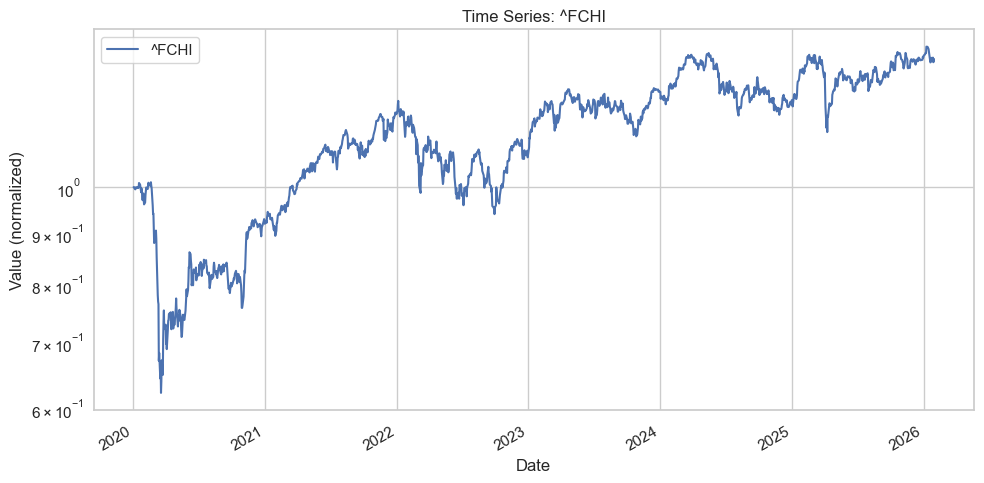

In [49]:
plot_time_series(prices_df, tickers, start_date=start_date_prices, end_date=end_date_prices, normalize=True, log_scale=True)

In [45]:
mc_tickers = ['ATO.PA']
# Fetch historical market cap using price * shares outstanding


In [46]:
# Fetch historical market cap using price * shares outstanding
start_date = '2020-01-01'
end_date = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')
mc_df = get_historical_market_cap(mc_tickers, start_date, end_date)
mc_df.head()

[*********************100%***********************]  1 of 1 completed


,ATO.PA
Date,
2020-01-02,6.016702e+11
2020-01-03,5.987990e+11
2020-01-06,5.914616e+11
2020-01-07,6.141119e+11
2020-01-08,6.113394e+11


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: ATO.PA'}, xlabel='Date', ylabel='Value (normalized)'>)

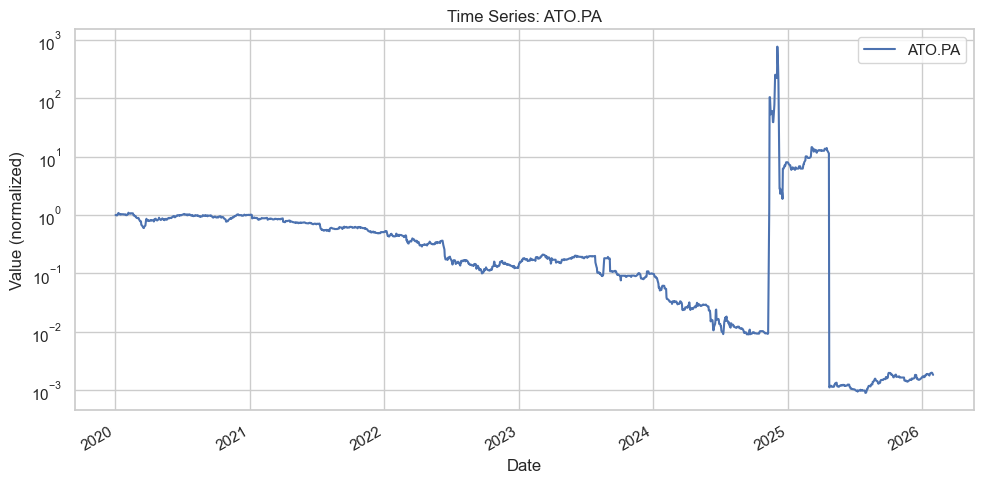

In [48]:
# Plot a few tickers (normalized for comparability)
plot_time_series(mc_df, mc_tickers, start_date=start_date, end_date=end_date, normalize=True, log_scale=True)

Atos SE (ATO.PA) is listed on Euronext Paris and is a component of the SBF 120 index. 
While historically part of the CAC 40, Atos was removed from the benchmark index in 2021 due to a drop in market capitalization. 
Key index associations and classifications:
Primary Index: SBF 120
Sector: Information Technology Services
Market: Euronext Paris (Compartment A) 
As of early 2025, the company is undergoing a restructuring process, including a reverse stock split, but remains listed on the Euronext Paris exchange. 

In [ ]:
# Export to CSV
out_path = '/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/data/market_cap.csv'
export_market_cap_to_csv(mc_df, out_path)
out_path

In [4]:
df = get_yahoo_components_for_index_symbol('SBF120', columns=['symbol', 'shortName'])
df.head()

/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/qf/core/data.py:650: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


,symbol
0,^SBF120
